# 04 Albums EDA

The analysis focuses on:
- album types
- number of tracks per album
- release patterns over time
- release date precision
- artist-album relationships
- how album information may support the recommendation system

## 1. Load Albums Data

In [1]:
from pathlib import Path
import sys
import warnings

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from config.paths import DUCKDB_PATH

con = duckdb.connect(DUCKDB_PATH)

In [3]:
albums = con.execute("SELECT * FROM albums").df()

albums.shape

(75511, 16)

In [4]:
albums.head()

,column00,album_type,artist_id,available_markets,external_urls,href,id,images,name,release_date,release_date_precision,total_tracks,track_id,track_name_prev,uri,type
0,0,single,3DiDSECUqqY1AuBP8qtaIa,"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",{'spotify': 'https://open.spotify.com/album/1g...,https://api.spotify.com/v1/albums/1gAM7M4rBwEb...,1gAM7M4rBwEbSPeAQR2nx1,"[{'height': 640, 'url': 'https://i.scdn.co/ima...",If I Ain't Got You EP,2019-02-08,day,6,2iejTMy9XZ8Gaae0aQ2yl0,track_32,spotify:album:1gAM7M4rBwEbSPeAQR2nx1,album
1,1,album,6s1pCNXcbdtQJlsnM1hRIA,"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",{'spotify': 'https://open.spotify.com/album/4K...,https://api.spotify.com/v1/albums/4KfJZV7WfolY...,4KfJZV7WfolYlxBzOTo66s,"[{'height': 640, 'url': 'https://i.scdn.co/ima...",Shostakovich Symphony No.5 - Four Romances on ...,2019-03-01,day,8,1WQfghEjszJJ4H8MAWrQ2C,track_11,spotify:album:4KfJZV7WfolYlxBzOTo66s,album
2,2,single,5YjfNaHq05WrwldRe1QSBc,"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",{'spotify': 'https://open.spotify.com/album/7n...,https://api.spotify.com/v1/albums/7nLYY7uAVUb5...,7nLYY7uAVUb57kpd7tZxnS,"[{'height': 640, 'url': 'https://i.scdn.co/ima...",Take My Bass,2019-03-14,day,1,3jJKj4QTK3v18ZSwpk7AcV,track_15,spotify:album:7nLYY7uAVUb57kpd7tZxnS,album
3,3,single,2G9Vc16JCpnZmK4uGH46Fa,"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",{'spotify': 'https://open.spotify.com/album/6p...,https://api.spotify.com/v1/albums/6p20Rt4x2Qn5...,6p20Rt4x2Qn5mUMRi1s6pj,"[{'height': 640, 'url': 'https://i.scdn.co/ima...",Hypnotizing (Are U),2016-11-16,day,1,1xGtDafUZbHyYC3Xarcbrj,track_46,spotify:album:6p20Rt4x2Qn5mUMRi1s6pj,album
4,4,single,2dwM9OcE4c3Ph1UBINSodx,"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",{'spotify': 'https://open.spotify.com/album/1X...,https://api.spotify.com/v1/albums/1XeoOqC1q7U2...,1XeoOqC1q7U2iyLEQJ64cu,"[{'height': 640, 'url': 'https://i.scdn.co/ima...",Sunshine,2018-07-20,day,1,0gWtsXvXOzAT6FtM3ur8in,track_10,spotify:album:1XeoOqC1q7U2iyLEQJ64cu,album


## 2. Basic Dataset Information

In [5]:
albums.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75511 entries, 0 to 75510
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   column00                75511 non-null  int64 
 1   album_type              75511 non-null  object
 2   artist_id               75511 non-null  object
 3   available_markets       75511 non-null  object
 4   external_urls           75511 non-null  object
 5   href                    75511 non-null  object
 6   id                      75511 non-null  object
 7   images                  75511 non-null  object
 8   name                    75511 non-null  object
 9   release_date            75511 non-null  object
 10  release_date_precision  75511 non-null  object
 11  total_tracks            75511 non-null  int64 
 12  track_id                75511 non-null  object
 13  track_name_prev         75511 non-null  object
 14  uri                     75511 non-null  object
 15  ty

In [6]:
albums.describe(include="all")

,column00,album_type,artist_id,available_markets,external_urls,href,id,images,name,release_date,release_date_precision,total_tracks,track_id,track_name_prev,uri,type
count,75511.000000,75511,75511,75511,75511,75511,75511,75511,75511,75511,75511,75511.000000,75511,75511,75511,75511
unique,NaN,3,39057,3145,75511,75511,75511,74213,66627,7459,3,NaN,75511,98,75511,1
top,NaN,single,0LyfQWJT6nXafLPZqxe9Of,"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",{'spotify': 'https://open.spotify.com/album/1g...,https://api.spotify.com/v1/albums/1gAM7M4rBwEb...,1gAM7M4rBwEbSPeAQR2nx1,"[{'height': 640, 'url': 'https://i.scdn.co/ima...",Spotify Singles,2019-03-15,day,NaN,2iejTMy9XZ8Gaae0aQ2yl0,track_7,spotify:album:1gAM7M4rBwEbSPeAQR2nx1,album
freq,NaN,39555,2443,49341,1,1,1,46,165,965,69620,NaN,1,1861,1,75511
mean,37755.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.235807,NaN,NaN,NaN,NaN
std,21798.292425,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.669811,NaN,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN
25%,18877.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN
50%,37755.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN
75%,56632.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.000000,NaN,NaN,NaN,NaN


In [7]:
albums.isna().sum().sort_values(ascending=False)

column00                  0
album_type                0
artist_id                 0
available_markets         0
external_urls             0
href                      0
id                        0
images                    0
name                      0
release_date              0
release_date_precision    0
total_tracks              0
track_id                  0
track_name_prev           0
uri                       0
type                      0
dtype: int64

In [8]:
albums.duplicated().sum()

0

The album dataset has no missing values. Some columns, such as `href`, `uri`, `external_urls`, and `images`, are mainly Spotify metadata and are not directly useful for EDA. The `type` column also only contains one value, so it does not add analytical value.

In [21]:
albums["type"].value_counts()

type
album    75511
Name: count, dtype: int64

In [24]:
albums[["id", "name", "track_id"]].nunique()

id          75511
name        66627
track_id    75511
dtype: int64

## 3. Album Type Distribution

In [9]:
albums["album_type"].value_counts()

album_type
single         39555
album          32636
compilation     3320
Name: count, dtype: int64

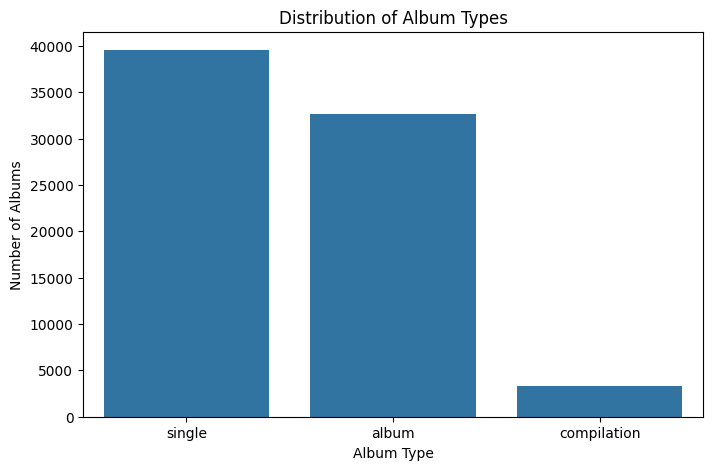

In [10]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=albums,
    x="album_type",
    order=albums["album_type"].value_counts().index
)

plt.title("Distribution of Album Types")
plt.xlabel("Album Type")
plt.ylabel("Number of Albums")

plt.show()

The dataset contains different album categories such as albums, singles, and compilations. 
Singles appear frequently, which reflects current music release trends where artists often release individual tracks instead of full albums.

## 4. Total Tracks per Album

In [11]:
albums["total_tracks"].describe()

count    75511.000000
mean         8.235807
std         11.669811
min          1.000000
25%          1.000000
50%          5.000000
75%         12.000000
max        977.000000
Name: total_tracks, dtype: float64

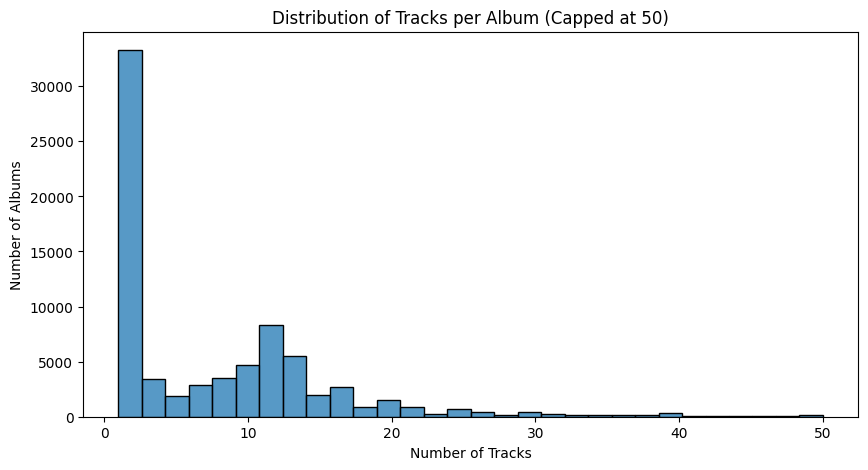

In [25]:
plt.figure(figsize=(10, 5))

sns.histplot(
    albums[albums["total_tracks"] <= 50]["total_tracks"],
    bins=30
)

plt.title("Distribution of Tracks per Album (Capped at 50)")
plt.xlabel("Number of Tracks")
plt.ylabel("Number of Albums")

plt.show()

The plot is capped at 50 tracks because a small number of albums have extremely high track counts. This makes the main distribution easier to read.

## 5. Album Release Years

In [13]:
albums["release_year"] = (
    albums["release_date"]
    .astype(str)
    .str[:4]
)

albums["release_year"] = pd.to_numeric(
    albums["release_year"],
    errors="coerce"
)

In [14]:
albums["release_year"].describe()

count    75511.000000
mean      2012.652898
std         10.103824
min       1886.000000
25%       2012.000000
50%       2017.000000
75%       2018.000000
max       2019.000000
Name: release_year, dtype: float64

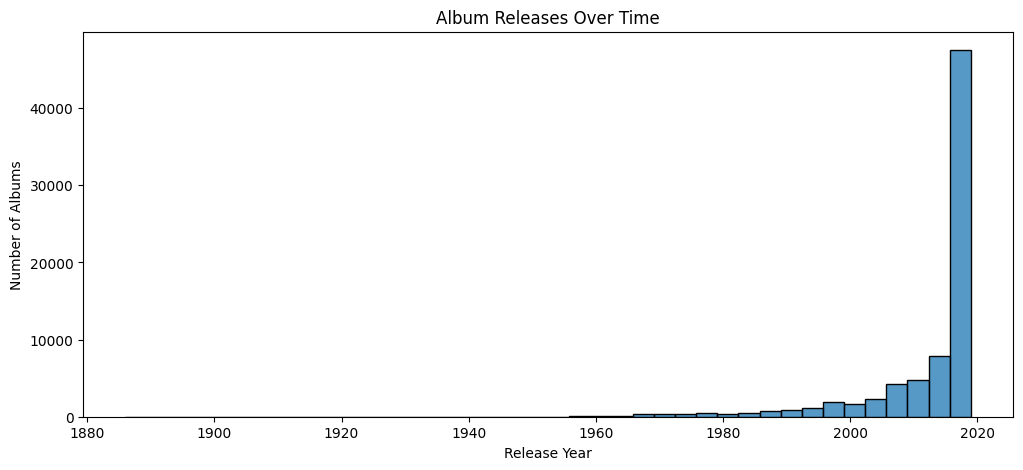

In [15]:
plt.figure(figsize=(12, 5))

sns.histplot(
    albums["release_year"].dropna(),
    bins=40
)

plt.title("Album Releases Over Time")
plt.xlabel("Release Year")
plt.ylabel("Number of Albums")

plt.show()

Most releases in this dataset are concentrated in the 2010s, with the latest release year being 2019. This suggests that the dataset is relatively modern, but not fully up to date.

## 6. Release Date Precision

In [16]:
albums["release_date_precision"].value_counts()

release_date_precision
day      69620
year      5846
month       45
Name: count, dtype: int64

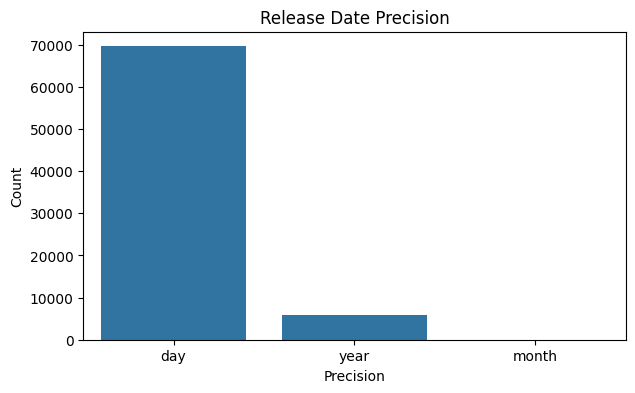

In [17]:
plt.figure(figsize=(7, 4))

sns.countplot(
    data=albums,
    x="release_date_precision",
    order=albums["release_date_precision"].value_counts().index
)

plt.title("Release Date Precision")
plt.xlabel("Precision")
plt.ylabel("Count")

plt.show()

## 7. Albums per Artist ID

In [18]:
top_album_artists = (
    albums["artist_id"]
    .value_counts()
    .head(20)
    .reset_index()
)

top_album_artists.columns = [
    "artist_id",
    "number_of_albums"
]

top_album_artists

,artist_id,number_of_albums
0,0LyfQWJT6nXafLPZqxe9Of,2443
1,5aIqB5nVVvmFsvSdExz408,85
2,7y97mc3bZRFXzT2szRM4L4,60
3,1Cs0zKBU1kc0i8ypK3B9ai,59
4,4NJhFmfw43RLBLjQvxDuRS,57
5,0SfsnGyD8FpIN4U4WCkBZ5,55
6,0spHbv2fw49lDMkbOAdaqX,45
7,6kACVPfCOnqzgfEF5ryl0x,45
8,7f5Zgnp2spUuuzKplmRkt7,44
9,1mYsTxnqsietFxj1OgoGbG,43


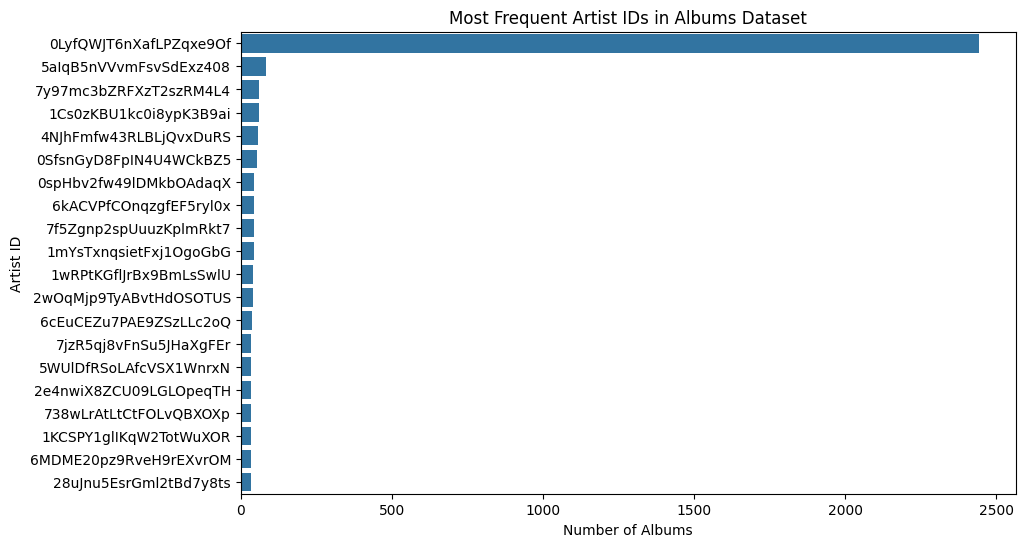

In [19]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_album_artists,
    x="number_of_albums",
    y="artist_id"
)

plt.title("Most Frequent Artist IDs in Albums Dataset")
plt.xlabel("Number of Albums")
plt.ylabel("Artist ID")

plt.show()

## 8. Album URI and Spotify Links

In [20]:
albums[["name", "uri", "href"]].head()

,name,uri,href
0,If I Ain't Got You EP,spotify:album:1gAM7M4rBwEbSPeAQR2nx1,https://api.spotify.com/v1/albums/1gAM7M4rBwEb...
1,Shostakovich Symphony No.5 - Four Romances on ...,spotify:album:4KfJZV7WfolYlxBzOTo66s,https://api.spotify.com/v1/albums/4KfJZV7WfolY...
2,Take My Bass,spotify:album:7nLYY7uAVUb57kpd7tZxnS,https://api.spotify.com/v1/albums/7nLYY7uAVUb5...
3,Hypnotizing (Are U),spotify:album:6p20Rt4x2Qn5mUMRi1s6pj,https://api.spotify.com/v1/albums/6p20Rt4x2Qn5...
4,Sunshine,spotify:album:1XeoOqC1q7U2iyLEQJ64cu,https://api.spotify.com/v1/albums/1XeoOqC1q7U2...


## 9. Album-Level Notes for Recommendation System

Album information can provide useful context for recommendations in addition to track-level audio features.

For example:
- tracks from the same album often share similar production styles or themes
- release year can help distinguish between older and newer music preferences
- album types such as singles or compilations may influence listening behavior
- albums may help group related tracks together within recommendations

Combining album-level information with artist and track features could improve recommendation quality and diversity.

## 10. Initial Notes

The album dataset contains a broad mix of albums, singles, and compilations across many years. 
Most releases contain relatively small track counts, while a smaller number represent larger full-length albums.

Overall, the dataset provides useful album-level context that can later support the recommendation system together with artist and track features.

In [26]:
con.close()